In [1]:
!pip install torch torchvision

In [8]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from src.utils import load_cifar10_longtail
import numpy as np
from tqdm import tqdm # Thư viện hiện thanh tiến trình

# 1. Thiết lập thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải Model DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# 3. Transform chuẩn
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Lớp hỗ trợ để đưa dữ liệu vào DataLoader ---
class CifarLongtailDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

# 4. Hàm trích xuất đặc trưng tối ưu (Xử lý theo Batch)
def extract_features_fast(X_images, batch_size=32):
    dataset = CifarLongtailDataset(X_images, transform=transform)
    # DataLoader giúp gộp các ảnh thành Batch để xử lý song song
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    # tqdm sẽ tạo ra thanh tiến trình cực đẹp
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

# --- THỰC THI ---

X_longtail, Y_longtail = load_cifar10_longtail('../data/cifar-10-batches-py', imbalance_ratio=0.1)

# Trích xuất với Batch size 64 (Nếu máy có GPU mạnh bạn có thể tăng lên 128)
X_features = extract_features_fast(X_longtail, batch_size=64)

print(f"Xong! Kích thước mảng đặc trưng: {X_features.shape}")

# --- QUAN TRỌNG: Lưu lại để không phải chạy lại lần nữa ---
# Bạn hãy tạo folder 'processed_data' nếu chưa có
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_features_cifar_0.1.npy', X_features)
np.save('../data/processed/Y_longtail_cifar_0.1.npy', Y_longtail)
print("Đã lưu đặc trưng vào thư mục data/processed/")

Đang sử dụng thiết bị: cpu


Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main


Lớp 0: giữ lại 5000 ảnh
Lớp 1: giữ lại 3871 ảnh
Lớp 2: giữ lại 2997 ảnh
Lớp 3: giữ lại 2320 ảnh
Lớp 4: giữ lại 1796 ảnh
Lớp 5: giữ lại 1391 ảnh
Lớp 6: giữ lại 1077 ảnh
Lớp 7: giữ lại 834 ảnh
Lớp 8: giữ lại 645 ảnh
Lớp 9: giữ lại 500 ảnh


Đang trích xuất đặc trưng: 100%|██████████| 320/320 [18:55<00:00,  3.55s/it]


Xong! Kích thước mảng đặc trưng: (20431, 384)
Đã lưu đặc trưng vào thư mục data/processed/


In [1]:
import numpy as np
import sys
import os
from sklearn.cluster import KMeans

# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model import hierarchical_kmeans_resampling

# 2. Load dữ liệu đặc trưng đã lưu (Đảm bảo đúng đường dẫn trong ảnh của bạn)
X_features = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

print(f"Đã load xong X_features: {X_features.shape}")
print(f"Đã load xong Y_longtail: {Y_longtail.shape}")

Đã load xong X_features: (20431, 384)
Đã load xong Y_longtail: (20431,)


Đang chạy trên thiết bị: cpu
Đang chạy Hierarchical K-means Resampling (Meta FAIR)...
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:17<00:00,  1.75s/it]
Đang gán nhãn lại cho toàn bộ dữ liệu (Sklearn KMeans)...
Đang nhặt tối đa 6 ảnh mỗi cụm (Unsupervised)...
--- XONG! ---
Tổng số ảnh thu được: 1655


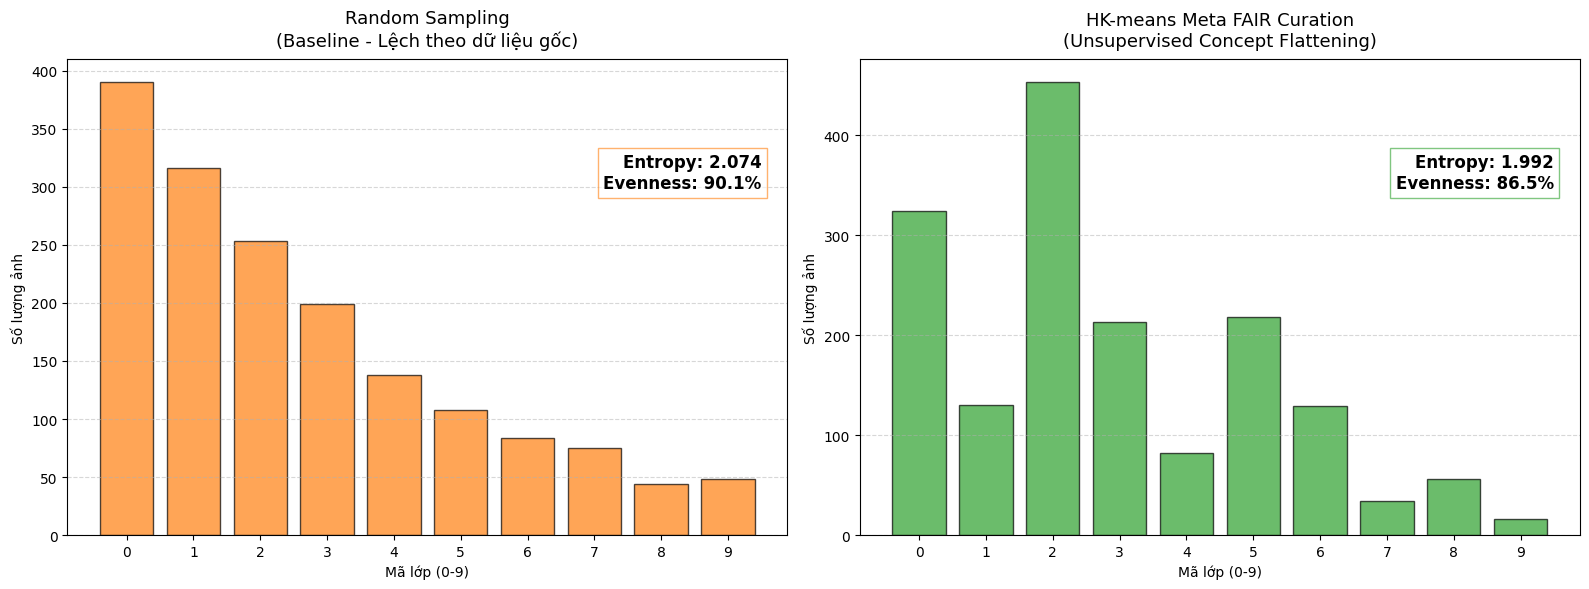

In [55]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy.stats import entropy
import sys
from tqdm import tqdm
from src_author.hierarchical_kmeans_gpu import hierarchical_kmeans_with_resampling

# Vá lỗi tương thích NumPy 2.0
if not hasattr(np, 'Inf'):
    np.Inf = np.inf

# --- 1. CHUẨN HÓA VÀ CHUẨN BỊ DỮ LIỆU ---
X_feat_norm_np = normalize(X_features, axis=1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X_gpu = torch.from_numpy(X_feat_norm_np).to(device).float()

print(f"Đang chạy trên thiết bị: {device}")

# --- 2. CHẠY HK-MEANS BẢN GỐC CỦA TÁC GIẢ (META FAIR) ---
n_clusters_list = [1500, 1000, 500] 
n_levels_val = 3
sample_sizes_val = [5, 2, 2]         
n_resamples_val = 10                 
sample_strategy_val = "closest"      

print("Đang chạy Hierarchical K-means Resampling (Meta FAIR)...")
centroids_cifar_raw = hierarchical_kmeans_with_resampling(
    data=X_gpu, 
    n_clusters=n_clusters_list, 
    n_levels=n_levels_val, 
    sample_sizes=sample_sizes_val, 
    n_resamples=n_resamples_val, 
    num_init=1,
    sample_strategy=sample_strategy_val
)

# --- 3. TRÍCH XUẤT VÀ GÁN NHÃN LẠI ---
centroids_final_np = centroids_cifar_raw[-1]["centroids"].cpu().numpy()
n_final_clusters = n_clusters_list[-1] 

print("Đang gán nhãn lại cho toàn bộ dữ liệu (Sklearn KMeans)...")
# Khởi tạo KMeans với centroids từ HK-means để gán nhãn chính xác cho 20k ảnh
km_fine = KMeans(n_clusters=n_final_clusters, init=centroids_final_np, n_init=1).fit(X_feat_norm_np)
labels_fine = km_fine.labels_

# --- 4. CHIẾN THUẬT LÀM PHẲNG TỰ ĐỘNG (UNSUPERVISED SAMPLING) ---
# Mục tiêu: Nhặt ảnh đều trên các concept để tự động phẳng hóa
samples_per_cluster = 6 
curated_idx = []

print(f"Đang nhặt tối đa {samples_per_cluster} ảnh mỗi cụm (Unsupervised)...")

for i in range(n_final_clusters):
    idx_in_cluster = np.where(labels_fine == i)[0]
    if len(idx_in_cluster) == 0: continue
    
    # Tính khoảng cách của ảnh trong cụm tới tâm cụm đó
    dists = np.linalg.norm(X_feat_norm_np[idx_in_cluster] - centroids_final_np[i], axis=1)
    
    # Lấy N ảnh gần tâm nhất
    n_take = min(len(idx_in_cluster), samples_per_cluster)
    top_local_indices = np.argsort(dists)[:n_take]
    
    curated_idx.extend(idx_in_cluster[top_local_indices])

Y_curated_new = Y_longtail[curated_idx]

print(f"--- XONG! ---")
print(f"Tổng số ảnh thu được: {len(Y_curated_new)}")

# --- 5. VẼ BIỂU ĐỒ SO SÁNH VÀ ĐO ENTROPY ---
def plot_distribution(y_data, title, color):
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    evenness = ent / np.log(10)
    
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh')
    plt.title(title, fontsize=13, pad=10)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# Chuẩn bị tập Random cùng kích thước để đối chứng
random_indices = np.random.choice(len(Y_longtail), len(Y_curated_new), replace=False)
Y_random_subset = Y_longtail[random_indices]

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_distribution(Y_random_subset, "Random Sampling\n(Baseline - Lệch theo dữ liệu gốc)", "tab:orange")

plt.subplot(1, 2, 2)
plot_distribution(Y_curated_new, "HK-means Meta FAIR Curation\n(Unsupervised Concept Flattening)", "tab:green")

plt.tight_layout()
plt.show()

In [45]:
# --- 1. Lấy mẫu ngẫu nhiên (Random Sampling - Baseline) ---
# Chọn đại 1000 ảnh từ toàn bộ dữ liệu gốc
random_indices = np.random.choice(len(X_features), 1600, replace=False)
Y_random_subset = Y_longtail[random_indices]



In [46]:
import matplotlib.pyplot as plt




print(f"Số lượng mẫu tập Random: {len(Y_random_subset)}")
print(f"Số lượng mẫu tập HK-means: {len(Y_curated_subset)}")

Số lượng mẫu tập Random: 1600
Số lượng mẫu tập HK-means: 1655


Tổng số ảnh tập Curated: 1655


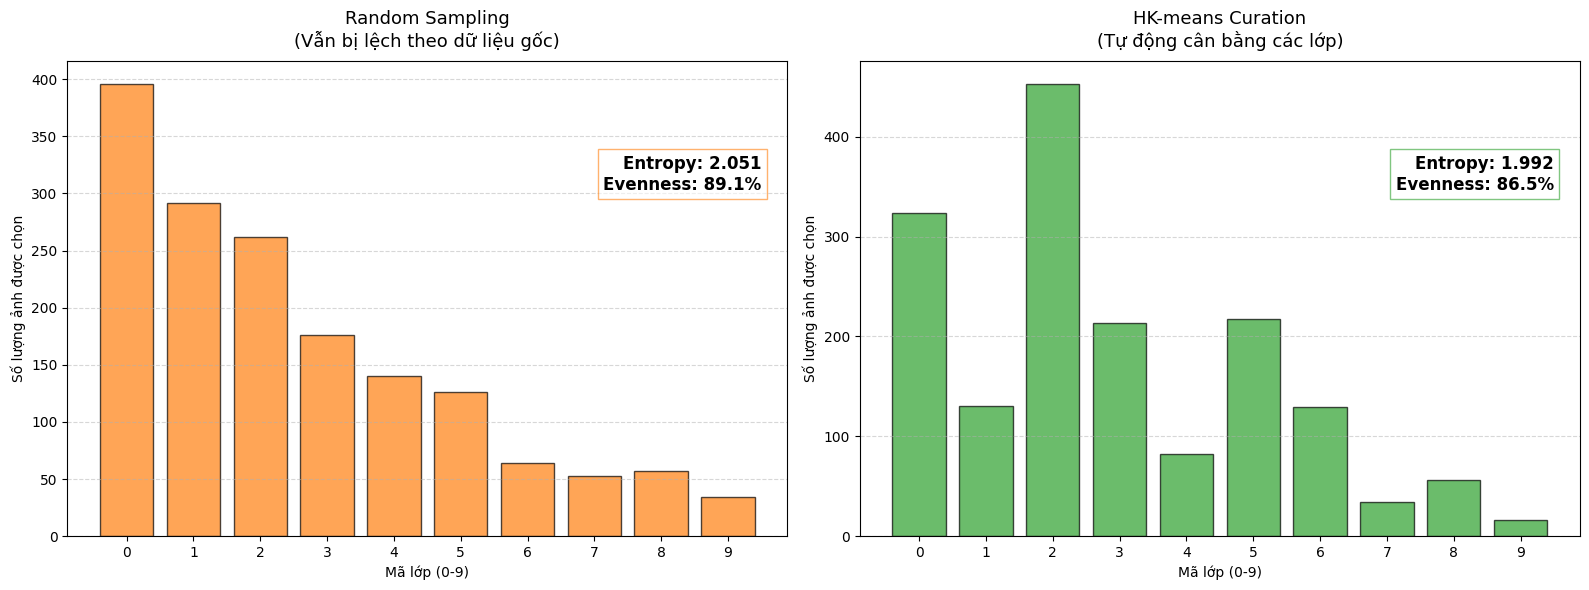

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng từng lớp
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG (EVENNESS)
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) cho 10 lớp
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    bars = plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text box ở góc trên bên phải của mỗi subplot
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=13, pad=10)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(16, 6))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Đảm bảo Y_random_subset đã được định nghĩa ở bước trước
plot_distribution(Y_random_subset, "Random Sampling\n(Vẫn bị lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Ours)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new là biến kết quả từ hàm Meta FAIR bạn vừa chạy
plot_distribution(Y_curated_new, "HK-means Curation\n(Tự động cân bằng các lớp)", "tab:green")

print(f"Tổng số ảnh tập Curated: {len(Y_curated_new)}")
plt.tight_layout()
plt.show()